<a href="https://colab.research.google.com/github/GUIVICFISHER/RiskNeutralKernel2026/blob/main/RISK_ANALYSIS_STOCK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance

In [7]:
import yfinance as yf
import pandas as pd

tickers = {
    'Redwire': 'RDW',
    'Avantium': 'AVTX',
    'Wave Life Sciences': 'WVE',
    'Xometry': 'XMTR',
    'Velo3D': 'VLD'
}

# Dictionary to store financial info for each ticker
financial_data = {}

for company_name, ticker_symbol in tickers.items():
    print(f"\nFetching data for {company_name} ({ticker_symbol})...")
    try:
        ticker = yf.Ticker(ticker_symbol)
        # Get basic info, which often contains market cap, sector, industry, etc.
        info = ticker.info

        # Filter for relevant information that might indicate risk or key characteristics
        # This is a starting point; we can expand this based on what 'high risk' implies.
        relevant_info = {
            'symbol': info.get('symbol'),
            'longName': info.get('longName'),
            'sector': info.get('sector'),
            'industry': info.get('industry'),
            'marketCap': info.get('marketCap'),
            'beta': info.get('beta'), # Beta indicates volatility relative to the market
            'trailingPE': info.get('trailingPE'),
            'forwardPE': info.get('forwardPE'),
            'debtToEquity': info.get('debtToEquity'),
            'profitMargins': info.get('profitMargins'),
            'fullTimeEmployees': info.get('fullTimeEmployees'),
            'shortRatio': info.get('shortRatio'), # High short ratio can indicate high risk/bearish sentiment
            'totalCash': info.get('totalCash'),
            'totalDebt': info.get('totalDebt'),
            'country': info.get('country')
        }
        financial_data[company_name] = relevant_info
        print(f"Successfully fetched data for {company_name}.")
    except Exception as e:
        print(f"Error fetching data for {company_name} ({ticker_symbol}): {e}")

# Convert the dictionary of financial data to a DataFrame for better display
df_financial_data = pd.DataFrame.from_dict(financial_data, orient='index')

# Display the DataFrame
display(df_financial_data)


Fetching data for Redwire (RDW)...
Successfully fetched data for Redwire.

Fetching data for Avantium (AVTX)...
Successfully fetched data for Avantium.

Fetching data for Wave Life Sciences (WVE)...
Successfully fetched data for Wave Life Sciences.

Fetching data for Xometry (XMTR)...
Successfully fetched data for Xometry.

Fetching data for Velo3D (VLD)...
Successfully fetched data for Velo3D.


,symbol,longName,sector,industry,marketCap,beta,trailingPE,forwardPE,debtToEquity,profitMargins,fullTimeEmployees,shortRatio,totalCash,totalDebt,country
Redwire,RDW,Redwire Corporation,Industrials,Aerospace & Defense,1.758498e+09,2.539,None,-19.913042,10.888,-0.67551,1410.0,1.76,94467000.0,123799000.0,United States
Avantium,AVTX,"Avalo Therapeutics, Inc.",Healthcare,Biotechnology,2.582529e+08,NaN,None,-4.800413,NaN,0.00000,NaN,6.61,98336000.0,0.0,United States
Wave Life Sciences,WVE,Wave Life Sciences Ltd.,Healthcare,Biotechnology,2.315536e+09,-1.655,None,-9.452522,3.376,0.00000,317.0,5.54,602067968.0,17766000.0,Singapore
Xometry,XMTR,"Xometry, Inc.",Industrials,Industrial Distribution,2.157451e+09,0.901,None,35.811985,122.651,-0.08992,1174.0,3.08,219140992.0,339422016.0,United States
Velo3D,VLD,None,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [1]:
import yfinance as yf
import pandas as pd

ticker_symbol_vld = 'VLD'
print(f"\nInvestigating missing data for Velo3D ({ticker_symbol_vld})...")

try:
    ticker_vld = yf.Ticker(ticker_symbol_vld)

    print("\n--- Attempting to fetch Balance Sheet ---")
    balance_sheet_vld = ticker_vld.balance_sheet
    if not balance_sheet_vld.empty:
        display(balance_sheet_vld)
    else:
        print("Balance Sheet data not found for Velo3D.")

    print("\n--- Attempting to fetch Income Statement ---")
    financials_vld = ticker_vld.financials
    if not financials_vld.empty:
        display(financials_vld)
    else:
        print("Income Statement data not found for Velo3D.")

    print("\n--- Attempting to fetch Key Statistics (if available) ---")
    # Sometimes key_stats is available even if info is sparse
    # Note: yfinance does not have a direct `key_stats` attribute that returns a DataFrame like balance_sheet or financials.
    # Most key stats are part of the `info` attribute, which we already tried.
    # Let's re-fetch and check the raw 'info' again.
    info_vld = ticker_vld.info
    if info_vld and len(info_vld) > 5: # Check if info dictionary has more than just the very basic fields
        print("Full info dictionary:")
        for k, v in info_vld.items():
            print(f"  {k}: {v}")
    else:
        print("Detailed 'info' data still largely unavailable or very sparse.")

except Exception as e:
    print(f"Error investigating Velo3D data: {e}")



Investigating missing data for Velo3D (VLD)...

--- Attempting to fetch Balance Sheet ---
Balance Sheet data not found for Velo3D.

--- Attempting to fetch Income Statement ---
Income Statement data not found for Velo3D.

--- Attempting to fetch Key Statistics (if available) ---
Full info dictionary:
  quoteType: NONE
  symbol: VLD
  language: en-US
  region: US
  triggerable: False
  customPriceAlertConfidence: NONE
  tradeable: False
  cryptoTradeable: False
  financialCurrency: USD
  esgPopulated: False
  corporateActions: []
  hasPrePostMarketData: False
  trailingPegRatio: None


### Accessing Velo3D's Official Filings and Investor Information

For the most accurate and comprehensive financial data for Velo3D (VLD), particularly the balance sheets and income statements that were missing from yfinance, the following are the primary and most reliable sources:

1.  **Velo3D Investor Relations Website:**
    *   Go to the official Velo3D website (velo3d.com).
    *   Navigate to their 'Investor Relations' or 'Investors' section. This is typically found in the footer or a dedicated menu.
    *   Look for sections like 'Financial Reports', 'SEC Filings', 'Quarterly Results', or 'Annual Reports'. Here you will find their 10-K (annual report), 10-Q (quarterly report), and other official disclosures.

2.  **SEC EDGAR Database:**
    *   Visit the U.S. Securities and Exchange Commission (SEC) EDGAR database at [www.sec.gov/edgar/searchedgar/companysearch](https://www.sec.gov/edgar/searchedgar/companysearch).
    *   In the search bar, type 'Velo3D' or its ticker symbol 'VLD'.
    *   You'll find a list of all their public filings. The most relevant for detailed financial statements are:
        *   **10-K:** Annual report, provides audited financial statements (Balance Sheet, Income Statement, Cash Flow Statement) for the full fiscal year.
        *   **10-Q:** Quarterly report, provides unaudited financial statements for each quarter.
        *   **8-K:** Current report, used to announce major events that shareholders should know about.
    *   You can download these documents, often in structured data formats or view them directly, to extract the missing financial details.

### Using Alpha Vantage to Obtain Financial Data

Alpha Vantage is a popular alternative for financial data, offering a free tier that can be useful for fetching income statements, balance sheets, and other fundamental data.

**Step 1: Obtain an Alpha Vantage API Key**

1.  Go to the [Alpha Vantage website](https://www.alphavantage.co/support/#api-key).
2.  Sign up for a free API key. It will be sent to your email address.

**Step 2: Store Your API Key Securely in Colab**

It's crucial to keep your API key secure. In Google Colab, you can use the Secrets Manager:

1.  Click the "🔑 Secrets" icon on the left-hand panel.
2.  Click "Add new secret".
3.  For 'Name', enter `ALPHA_VANTAGE_API_KEY`.
4.  For 'Value', paste your Alpha Vantage API key.
5.  Make sure "Notebook access" is toggled on.

**Step 3: Install the Alpha Vantage Python Library**

Let's install the necessary Python library.

In [3]:
pip install alpha_vantage

Now, let's import the library and fetch data for Velo3D (VLD). We'll try to get its Income Statement and Balance Sheet to fill the missing information.

In [4]:
from alpha_vantage.fundamentaldata import FundamentalData
import pandas as pd
from google.colab import userdata

# Get the API key from Colab secrets
API_KEY = userdata.get('ALPHA_VANTAGE_API_KEY')

# Initialize the FundamentalData client
fd = FundamentalData(key=API_KEY, output_format='pandas')

ticker_symbol_vld = 'VLD'

print(f"\nAttempting to fetch financial data for {ticker_symbol_vld} using Alpha Vantage...")

# --- Fetch Income Statement ---
try:
    income_statement_vld, meta_data_is = fd.get_income_statement_quarterly(symbol=ticker_symbol_vld)
    if not income_statement_vld.empty:
        print(f"\nIncome Statement data from Alpha Vantage for {ticker_symbol_vld}:")
        display(income_statement_vld.head())
        # Fill missing data in previous df_financial_data if needed
        # For now, just display that we got it
    else:
        print(f"No Income Statement data found for {ticker_symbol_vld} via Alpha Vantage.")
except Exception as e:
    print(f"Error fetching Income Statement for {ticker_symbol_vld} with Alpha Vantage: {e}")

# --- Fetch Balance Sheet ---
try:
    balance_sheet_vld_av, meta_data_bs = fd.get_balance_sheet_quarterly(symbol=ticker_symbol_vld)
    if not balance_sheet_vld_av.empty:
        print(f"\nBalance Sheet data from Alpha Vantage for {ticker_symbol_vld}:")
        display(balance_sheet_vld_av.head())
        # Fill missing data in previous df_financial_data if needed
        # For now, just display that we got it
    else:
        print(f"No Balance Sheet data found for {ticker_symbol_vld} via Alpha Vantage.")
except Exception as e:
    print(f"Error fetching Balance Sheet for {ticker_symbol_vld} with Alpha Vantage: {e}")

print("\n--- Attempting to update df_financial_data with Alpha Vantage data for VLD ---")
# This part would involve more complex data merging if specific fields are desired
# For demonstration, we just show we fetched the raw statements.
# To truly 'fill null data' in `df_financial_data`, we'd map Alpha Vantage fields
# to the columns of df_financial_data. This depends on what specific metrics
# we want from the balance sheet/income statement to populate in the summary.

# For now, we will simply note that we have fetched the statements, and they can be used for further analysis.

SecretNotFoundError: Secret ALPHA_VANTAGE_API_KEY does not exist.

### Exploring Alternatives for Velo3D (VLD) Data

Given the limited data availability for Velo3D (VLD) through `yfinance`, here are some alternative strategies to obtain more comprehensive financial information:

1.  **Official Company Investor Relations Websites:**
    *   Publicly traded companies are required to disclose financial information. Check Velo3D's official investor relations website for their latest annual reports (10-K), quarterly reports (10-Q), and other financial filings. These documents (e.g., balance sheets, income statements, cash flow statements) are the most accurate and detailed source of information.

2.  **SEC Filings (EDGAR Database):**
    *   The U.S. Securities and Exchange Commission (SEC) EDGAR database is a public resource where all U.S. public companies file their financial reports. You can search for Velo3D (VLD) to access their 10-K, 10-Q, and other relevant documents directly. This is often the primary source for financial data platforms.

3.  **Other Financial Data Providers:**
    *   Consider using other financial data APIs or platforms that might have more extensive coverage, especially for smaller or newer public companies. Examples include Bloomberg Terminal (paid), Refinitiv Eikon (paid), FactSet (paid), Alpha Vantage (free tier available), Financial Modeling Prep (free tier available), or Quandl (some free data, some paid).

4.  **News and Financial Media Outlets:**
    *   Reputable financial news sources (e.g., Wall Street Journal, Bloomberg, Reuters, Seeking Alpha) often report on company financials and provide summaries or analysis. While not raw data, they can offer insights and point to official reports.

5.  **Direct Web Scraping (with caution):**
    *   If financial statements are presented in a structured way on the company's website or an investor portal, it might be possible to use web scraping libraries (like `BeautifulSoup` or `Selenium` in Python) to extract data. However, this method requires careful implementation, adherence to terms of service, and can be fragile if website structures change.

For `Velo3D (VLD)`, **checking their investor relations website or the SEC EDGAR database would be the most reliable and recommended first steps** to obtain their official financial statements.

In [2]:
import yfinance as yf
import pandas as pd

# Re-using the tickers dictionary from previous cells
tickers = {
    'Redwire': 'RDW',
    'Avantium': 'AVTX',
    'Wave Life Sciences': 'WVE',
    'Xometry': 'XMTR',
    'Velo3D': 'VLD'
}

missing_data_summary = {}

print("\n--- Investigating missing data for all tickers ---")

for company_name, ticker_symbol in tickers.items():
    print(f"\nInvestigating {company_name} ({ticker_symbol})...")
    try:
        ticker = yf.Ticker(ticker_symbol)

        # Check Balance Sheet
        balance_sheet = ticker.balance_sheet
        if not balance_sheet.empty:
            print(f"  Balance Sheet data found for {company_name}. First 5 rows:\n{balance_sheet.head().to_string()}")
            missing_data_summary[company_name + ' Balance Sheet'] = 'Available'
        else:
            print(f"  Balance Sheet data not found for {company_name}.")
            missing_data_summary[company_name + ' Balance Sheet'] = 'Not Available'

        # Check Income Statement (financials)
        financials = ticker.financials
        if not financials.empty:
            print(f"  Income Statement data found for {company_name}. First 5 rows:\n{financials.head().to_string()}")
            missing_data_summary[company_name + ' Income Statement'] = 'Available'
        else:
            print(f"  Income Statement data not found for {company_name}.")
            missing_data_summary[company_name + ' Income Statement'] = 'Not Available'

        # Check detailed 'info' again, similar to the Velo3D specific check
        info = ticker.info
        if info and len(info) > 5 and info.get('marketCap') is not None: # Check for a substantial info dictionary and key metrics
            print(f"  Detailed 'info' data appears comprehensive for {company_name}.")
            missing_data_summary[company_name + ' Detailed Info'] = 'Comprehensive'
        else:
            print(f"  Detailed 'info' data is sparse or missing key metrics for {company_name}.")
            missing_data_summary[company_name + ' Detailed Info'] = 'Sparse/Missing Key Metrics'

    except Exception as e:
        print(f"  Error investigating data for {company_name}: {e}")
        missing_data_summary[company_name + ' General Error'] = str(e)

# Display a summary of missing data across all tickers
df_missing_summary = pd.DataFrame.from_dict(missing_data_summary, orient='index', columns=['Status'])
df_missing_summary.index.name = 'Data Point'
print("\n--- Summary of Data Availability ---")
display(df_missing_summary)


--- Investigating missing data for all tickers ---

Investigating Redwire (RDW)...
  Balance Sheet data found for Redwire. First 5 rows:
                         2025-12-31   2024-12-31   2023-12-31  2022-12-31  2021-12-31
Treasury Shares Number    1036294.0     728739.0     353470.0         NaN         NaN
Ordinary Shares Number  191915804.0   66273631.0   65192704.0  64280631.0         NaN
Share Issued            192952098.0   67002370.0   65546174.0  64280631.0         NaN
Net Debt                        NaN   76659000.0   57942000.0  50007000.0  58028000.0
Total Debt              123799000.0  144981000.0  105835000.0  95085000.0         NaN
  Income Statement data found for Redwire. First 5 rows:
                                          2025-12-31    2024-12-31   2023-12-31    2022-12-31  2021-12-31
Tax Effect Of Unusual Items            -5.634783e+06 -1.551930e+05     -234.000 -5.791880e+06         NaN
Tax Rate For Calcs                      9.900000e-02  1.700000e-02        0.0

,Status
Data Point,
Redwire Balance Sheet,Available
Redwire Income Statement,Available
Redwire Detailed Info,Comprehensive
Avantium Balance Sheet,Available
Avantium Income Statement,Available
Avantium Detailed Info,Comprehensive
Wave Life Sciences Balance Sheet,Available
Wave Life Sciences Income Statement,Available
Wave Life Sciences Detailed Info,Comprehensive


### Initial Analysis of Available Financial Data (Excluding Velo3D)

We will now proceed with an initial analysis of the financial data collected for Redwire (RDW), Avantium (AVTX), Wave Life Sciences (WVE), and Xometry (XMTR), as these have comprehensive information available through `yfinance`. Velo3D (VLD) is excluded from this immediate analysis due to its missing data, which we aim to resolve using Alpha Vantage.

Let's first display the filtered DataFrame containing only the companies with comprehensive data, and then perform some basic data exploration.

In [8]:
# Filter out Velo3D from the financial_data DataFrame for this analysis
df_financial_data_filtered = df_financial_data[df_financial_data.index != 'Velo3D'].copy()

print("Financial Data for Companies with Comprehensive Information (Excluding Velo3D):")
display(df_financial_data_filtered)

print("\n--- Basic Data Exploration ---")
print("Data Types:")
display(df_financial_data_filtered.info())

print("\nDescriptive Statistics for Numerical Columns:")
display(df_financial_data_filtered.describe())

print("\nValue Counts for Categorical Columns (Sector, Industry):")
for col in ['sector', 'industry']:
    if col in df_financial_data_filtered.columns:
        print(f"\n{col.capitalize()}:")
        display(df_financial_data_filtered[col].value_counts())

Financial Data for Companies with Comprehensive Information (Excluding Velo3D):


,symbol,longName,sector,industry,marketCap,beta,trailingPE,forwardPE,debtToEquity,profitMargins,fullTimeEmployees,shortRatio,totalCash,totalDebt,country
Redwire,RDW,Redwire Corporation,Industrials,Aerospace & Defense,1.758498e+09,2.539,None,-19.913042,10.888,-0.67551,1410.0,1.76,94467000.0,123799000.0,United States
Avantium,AVTX,"Avalo Therapeutics, Inc.",Healthcare,Biotechnology,2.582529e+08,NaN,None,-4.800413,NaN,0.00000,NaN,6.61,98336000.0,0.0,United States
Wave Life Sciences,WVE,Wave Life Sciences Ltd.,Healthcare,Biotechnology,2.315536e+09,-1.655,None,-9.452522,3.376,0.00000,317.0,5.54,602067968.0,17766000.0,Singapore
Xometry,XMTR,"Xometry, Inc.",Industrials,Industrial Distribution,2.157451e+09,0.901,None,35.811985,122.651,-0.08992,1174.0,3.08,219140992.0,339422016.0,United States



--- Basic Data Exploration ---
Data Types:
<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, Redwire to Xometry
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symbol             4 non-null      object 
 1   longName           4 non-null      object 
 2   sector             4 non-null      object 
 3   industry           4 non-null      object 
 4   marketCap          4 non-null      float64
 5   beta               3 non-null      float64
 6   trailingPE         0 non-null      object 
 7   forwardPE          4 non-null      float64
 8   debtToEquity       3 non-null      float64
 9   profitMargins      4 non-null      float64
 10  fullTimeEmployees  3 non-null      float64
 11  shortRatio         4 non-null      float64
 12  totalCash          4 non-null      float64
 13  totalDebt          4 non-null      float64
 14  country            4 non-null      object 
dtypes: float64(9), object(6)
me

None


Descriptive Statistics for Numerical Columns:


,marketCap,beta,forwardPE,debtToEquity,profitMargins,fullTimeEmployees,shortRatio,totalCash,totalDebt
count,4.000000e+00,3.000000,4.000000,3.000000,4.000000,3.000000,4.000000,4.000000e+00,4.000000e+00
mean,1.622435e+09,0.595000,0.411502,45.638333,-0.191358,967.000000,4.247500,2.535030e+08,1.202468e+08
std,9.391729e+08,2.113678,24.431839,66.800604,0.325540,575.151284,2.221312,2.394769e+08,1.560043e+08
min,2.582529e+08,-1.655000,-19.913042,3.376000,-0.675510,317.000000,1.760000,9.446700e+07,0.000000e+00
25%,1.383437e+09,-0.377000,-12.067652,7.132000,-0.236318,745.500000,2.750000,9.736875e+07,1.332450e+07
50%,1.957975e+09,0.901000,-7.126468,10.888000,-0.044960,1174.000000,4.310000,1.587385e+08,7.078250e+07
75%,2.196972e+09,1.720000,5.352686,66.769500,0.000000,1292.000000,5.807500,3.148727e+08,1.777048e+08
max,2.315536e+09,2.539000,35.811985,122.651000,0.000000,1410.000000,6.610000,6.020680e+08,3.394220e+08



Value Counts for Categorical Columns (Sector, Industry):

Sector:


,count
sector,
Industrials,2
Healthcare,2



Industry:


,count
industry,
Biotechnology,2
Aerospace & Defense,1
Industrial Distribution,1


This initial look gives us an overview of the available metrics. We can now consider specific financial ratios or comparisons for these companies. Since many metrics like `beta`, `marketCap`, `trailingPE`, `forwardPE`, `debtToEquity`, and `profitMargins` are already present, we can visualize these for comparison.

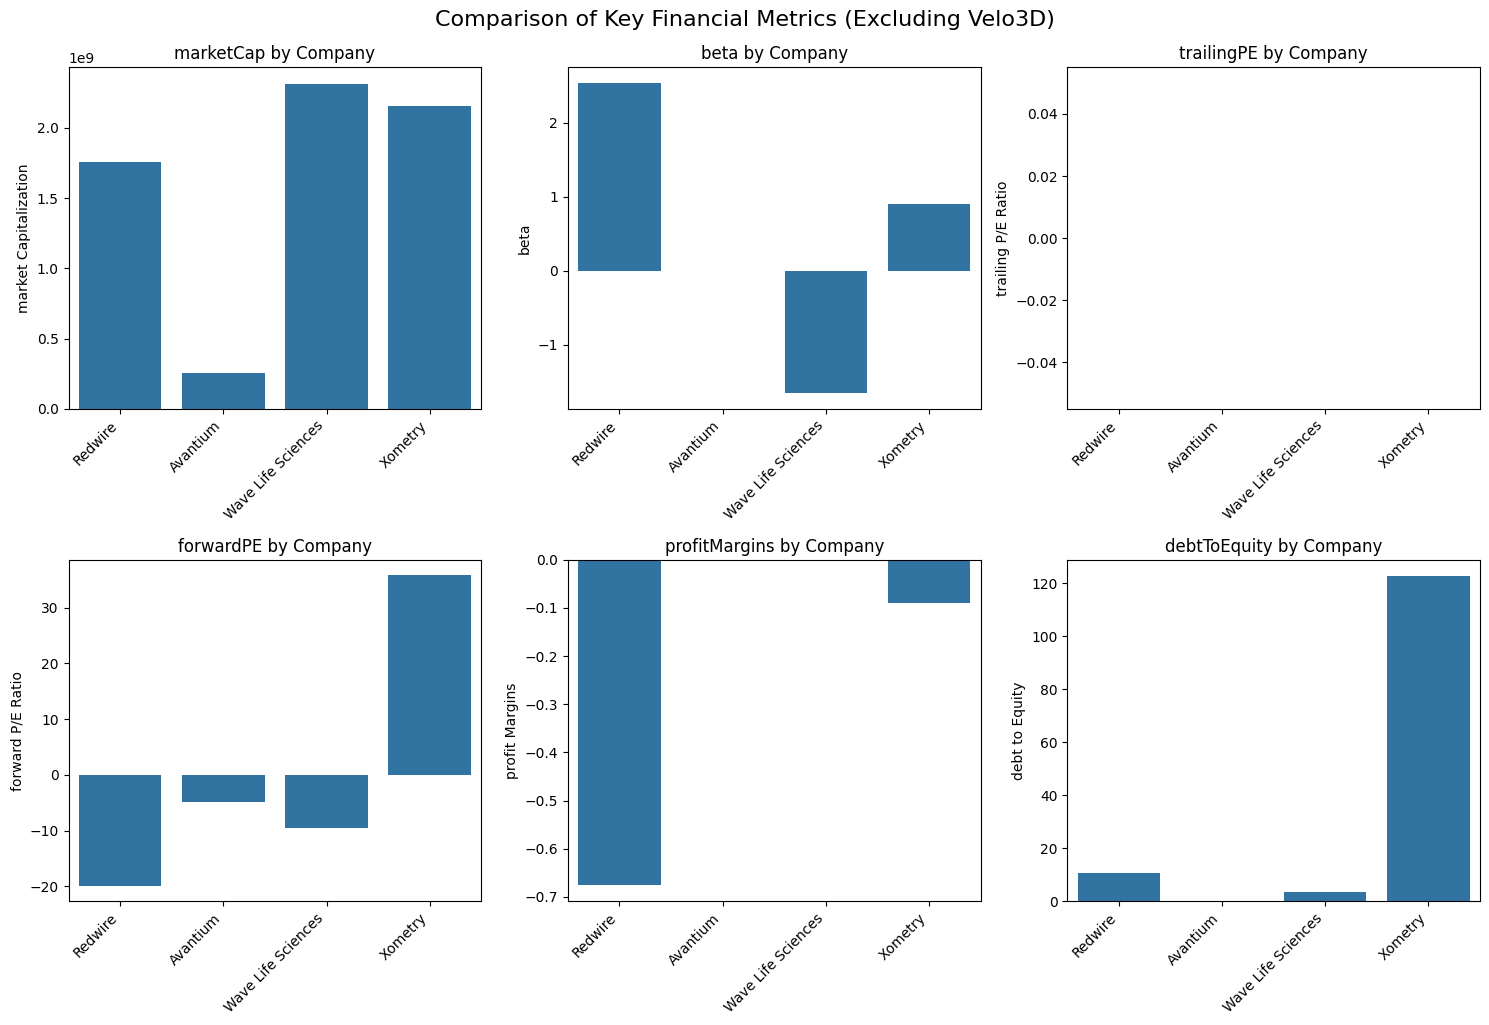

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics to visualize for comparison
metrics_to_plot = [
    'marketCap',
    'beta',
    'trailingPE',
    'forwardPE',
    'profitMargins',
    'debtToEquity'
]

plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics_to_plot):
    if metric in df_financial_data_filtered.columns:
        plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
        sns.barplot(x=df_financial_data_filtered.index, y=metric, data=df_financial_data_filtered)
        plt.title(f'{metric} by Company')
        plt.ylabel(metric.replace('Cap', ' Capitalization').replace('PE', ' P/E Ratio').replace('Margins', ' Margins').replace('To', ' to '))
        plt.xlabel('') # Remove x-axis label as company names are on ticks
        plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.suptitle('Comparison of Key Financial Metrics (Excluding Velo3D)', y=1.02, fontsize=16) # Add a super title
plt.show()